# Statistical analysis DESeq2

# Graphs bioinformatics

individuals

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import os
from matplotlib.lines import Line2D
from matplotlib import rcParams

# ── 1. STYLE CONFIGURATION ──────────────────────────────────────────────────
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']
rcParams['font.size'] = 12

sns.set_style("whitegrid", {'axes.edgecolor': 'black', 'grid.color': '.90', 'grid.linestyle': '-'})

# ── 2. PATHWAYS AND SETTINGS ────────────────────────────────────────────────
STUDIES = {
    'PRJNA46333': "/home/marcos/PRJNA46333/PRJNA46333_2/table/master_table_mag_sialidase_gtdb_deseq2.tsv",
}

OUTPUT_PATH = "/home/marcos/Imagens/Resultados in silico/Individuais/Final_DESeq2_Metabolic_Plot_PRJNA46333.png"

METABOLIC_PALETTE = {
    'Sialidases': '#9b59b6',
    'Transporters': '#e67e22',
    'Catabolic Pathway': '#27ae60',
    'Inactive': '#eeeeee'
}
GENE_LIST = ['has_nanH', 'has_nanE', 'has_nanK', 'has_nanA', 'has_nanT']

# ── 3. DATA INTEGRATION ──────────────────────────────────────────────────────
df_list = []
for study_id, path in STUDIES.items():
    if os.path.exists(path):
        temp_df = pd.read_csv(path, sep='\t')
        temp_df['Study'] = study_id
        df_list.append(temp_df)
    else:
        print(f"File not found: {path}")

df = pd.concat(df_list, ignore_index=True)

for col in ['baseMean', 'log2FoldChange', 'padj']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['padj'] = df['padj'].fillna(1.0)
df['log2FoldChange'] = df['log2FoldChange'].fillna(0.0)
df['baseMean'] = df['baseMean'].fillna(0.0)

for gene in GENE_LIST:
    if gene in df.columns:
        df[gene] = df[gene].astype(str).str.upper().isin(['YES', 'TRUE', '1'])

# ── 4. AGGREGATION AND FILTERING ────────────────────────────────────────────
perfil_counts = df.groupby(['Species'] + GENE_LIST).size().reset_index(name='count')
perfil_majoritario = perfil_counts.sort_values('count', ascending=False).drop_duplicates('Species')

df_filtrado = pd.merge(df, perfil_majoritario[['Species'] + GENE_LIST], on=['Species'] + GENE_LIST)

bin_counts = df_filtrado.groupby(['Study', 'Species']).size().reset_index(name='bin_count')

df_agg = df_filtrado.groupby(['Study', 'Species']).agg({
    'baseMean': 'mean',
    'log2FoldChange': 'mean',
    'padj': 'min',
    **{g: 'any' for g in GENE_LIST if g in df_filtrado.columns}
}).reset_index()

df_agg = pd.merge(df_agg, bin_counts, on=['Study', 'Species'])

study_counts = df_agg.groupby('Species')['Study'].nunique()
multi_study_species = set(study_counts[study_counts >= 2].index)

top_30_species = df_agg.groupby('Species')['baseMean'].sum().nlargest(30).index.tolist()
df_plot = df_agg[df_agg['Species'].isin(top_30_species)].copy()

species_order = df_plot.groupby('Species')['log2FoldChange'].mean().sort_values().index.tolist()
sp_to_y = {sp: i for i, sp in enumerate(species_order)}
df_plot['Y_idx'] = df_plot['Species'].map(sp_to_y)

# ── 5. RELATIVE ABUNDANCE ───────────────────────────────────────────────────
study_totals = df_plot.groupby('Study')['baseMean'].transform('sum')
df_plot['Relative_Abundance'] = (df_plot['baseMean'] / study_totals) * 100

# ── 6. FIGURE CONFIGURATION ─────────────────────────────────────────────────
num_sp = len(species_order)
fig, ax = plt.subplots(1, 1, figsize=(8, max(10, num_sp * 0.45)))

meta_df = df_plot.groupby('Species').agg({g: 'any' for g in GENE_LIST}).reset_index()

# ── 7. PLOTTING LOOP ────────────────────────────────────────────────────────
for study in STUDIES.keys():
    sub_df = df_plot[df_plot['Study'] == study]
    
    sizes = (sub_df['Relative_Abundance'] / df_plot['Relative_Abundance'].max() * 1200) + 60
    
    ax.scatter(x=sub_df['log2FoldChange'], y=sub_df['Y_idx'], s=sizes, color='white', 
               edgecolors='black', linewidths=1.2, alpha=1.0, zorder=3)
    
    for _, row in sub_df.iterrows():
        ax.text(row['log2FoldChange'], row['Y_idx'], str(int(row['bin_count'])), 
                ha='center', va='center', fontsize=9, fontweight='bold', color='black', zorder=4)
        
        sig = "***" if row['padj'] < 0.001 else "**" if row['padj'] < 0.01 else "*" if row['padj'] < 0.05 else ""
        if sig:
            ax.text(row['log2FoldChange'], row['Y_idx'] + 0.35, sig, ha='center', va='center',
                    fontsize=12, fontweight='bold', color='black', zorder=4)
            
    ax.axvline(x=0, color='gray', linestyle='--', lw=1.5, zorder=1)
    ax.set_title(f"{study}", fontweight='bold', fontsize=14, pad=15)
    ax.set_xlabel("Log₂ Fold Change\n(HC ← | → AD)", fontsize=11, fontweight='bold', labelpad=10)
    ax.tick_params(axis='x', labelsize=11)
    
    xmin, xmax = ax.get_xlim()
    ax.set_xlim(xmin * 1.20, xmax * 1.20)
    ax.set_ylim(-1, num_sp)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── 8. Y-AXIS LABELS AND METABOLIC BARS ─────────────────────────────────────
ax.set_yticks(range(num_sp))
ax.set_yticklabels(species_order, fontstyle='italic', fontsize=11)
ax.tick_params(axis='y', pad=80) 

for label in ax.get_yticklabels():
    if label.get_text() in multi_study_species:
        label.set_fontweight('bold')

for i, sp in enumerate(species_order):
    if sp in meta_df['Species'].values:
        row = meta_df[meta_df['Species'] == sp].iloc[0]
        metabolic_info = [('has_nanH', 'Sialidases'), ('has_nanT', 'Transporters'), ('cat', 'Catabolic Pathway')]

        for j, (g_key, p_key) in enumerate(metabolic_info):
            if g_key == 'cat':
                present = any(row.get(g, False) for g in ['has_nanA', 'has_nanE', 'has_nanK'])
            else:
                present = row.get(g_key, False)

            color = METABOLIC_PALETTE[p_key] if present else METABOLIC_PALETTE['Inactive']
            ax.add_patch(plt.Rectangle((-0.18 + (j * 0.05), i - 0.30), 0.035, 0.60, clip_on=False,
                                            transform=ax.get_yaxis_transform(), facecolor=color, edgecolor='black', lw=0.5))

# ── 9. GLOBAL LEGEND ────────────────────────────────────────────────────────
size_samples = [df_plot['Relative_Abundance'].max() * 0.1, df_plot['Relative_Abundance'].max() * 0.5, df_plot['Relative_Abundance'].max()]
size_legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=f'{val:.2f}%',
           markerfacecolor='white', markeredgecolor='black', markeredgewidth=1.2, alpha=1.0,
           markersize=np.sqrt(((val / df_plot['Relative_Abundance'].max()) * 1200) + 60))
    for val in size_samples if val > 0
]
if size_legend_elements:
    fig.legend(handles=size_legend_elements, title="Relative Abundance",
               loc='lower right', bbox_to_anchor=(0.90, 0.0351), ncol=1, frameon=True,
               title_fontproperties={'weight': 'bold'})

legend_els = [Line2D([0], [0], color=c, lw=10, label=l) for l, c in METABOLIC_PALETTE.items() if l != 'Inactive']
fig.legend(handles=legend_els, title="Metabolic Profile  ▌NanH  ▌NanT  ▌Catabolic",
           loc='lower left', bbox_to_anchor=(-0.2, 0.0351), ncol=1, frameon=True,
           title_fontproperties={'weight': 'bold'})

# ── 10. LAYOUT & SAVE ───────────────────────────────────────────────────────
plt.subplots_adjust(left=0.25, right=0.95, top=0.90, bottom=0.25)

plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import os
from matplotlib.lines import Line2D
from matplotlib import rcParams

# ── 1. STYLE CONFIGURATION ──────────────────────────────────────────────────
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']
rcParams['font.size'] = 12

sns.set_style("whitegrid", {'axes.edgecolor': 'black', 'grid.color': '.90', 'grid.linestyle': '-'})

# ── 2. PATHWAYS AND SETTINGS ────────────────────────────────────────────────
STUDIES = {
    'PRJEB59406': "/home/marcos/PRJEB59406/table/master_table_mag_sialidase_gtdb_deseq2.tsv", 
}

OUTPUT_PATH = "/home/marcos/Imagens/Resultados in silico/Individuais/Final_DESeq2_Metabolic_Plot_PRJEB59406.png"

METABOLIC_PALETTE = {
    'Sialidases': '#9b59b6',
    'Transporters': '#e67e22',
    'Catabolic Pathway': '#27ae60',
    'Inactive': '#eeeeee'
}
GENE_LIST = ['has_nanH', 'has_nanE', 'has_nanK', 'has_nanA', 'has_nanT']

# ── 3. DATA INTEGRATION ──────────────────────────────────────────────────────
df_list = []
for study_id, path in STUDIES.items():
    if os.path.exists(path):
        temp_df = pd.read_csv(path, sep='\t')
        temp_df['Study'] = study_id
        df_list.append(temp_df)
    else:
        print(f"File not found: {path}")

df = pd.concat(df_list, ignore_index=True)

for col in ['baseMean', 'log2FoldChange', 'padj']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['padj'] = df['padj'].fillna(1.0)
df['log2FoldChange'] = df['log2FoldChange'].fillna(0.0)
df['baseMean'] = df['baseMean'].fillna(0.0)

for gene in GENE_LIST:
    if gene in df.columns:
        df[gene] = df[gene].astype(str).str.upper().isin(['YES', 'TRUE', '1'])

# ── 4. AGGREGATION AND FILTERING ────────────────────────────────────────────
perfil_counts = df.groupby(['Species'] + GENE_LIST).size().reset_index(name='count')
perfil_majoritario = perfil_counts.sort_values('count', ascending=False).drop_duplicates('Species')

df_filtrado = pd.merge(df, perfil_majoritario[['Species'] + GENE_LIST], on=['Species'] + GENE_LIST)

bin_counts = df_filtrado.groupby(['Study', 'Species']).size().reset_index(name='bin_count')

df_agg = df_filtrado.groupby(['Study', 'Species']).agg({
    'baseMean': 'mean',
    'log2FoldChange': 'mean',
    'padj': 'min',
    **{g: 'any' for g in GENE_LIST if g in df_filtrado.columns}
}).reset_index()

df_agg = pd.merge(df_agg, bin_counts, on=['Study', 'Species'])

study_counts = df_agg.groupby('Species')['Study'].nunique()
multi_study_species = set(study_counts[study_counts >= 2].index)

top_30_species = df_agg.groupby('Species')['baseMean'].sum().nlargest(30).index.tolist()
df_plot = df_agg[df_agg['Species'].isin(top_30_species)].copy()

species_order = df_plot.groupby('Species')['log2FoldChange'].mean().sort_values().index.tolist()
sp_to_y = {sp: i for i, sp in enumerate(species_order)}
df_plot['Y_idx'] = df_plot['Species'].map(sp_to_y)

# ── 5. RELATIVE ABUNDANCE ───────────────────────────────────────────────────
study_totals = df_plot.groupby('Study')['baseMean'].transform('sum')
df_plot['Relative_Abundance'] = (df_plot['baseMean'] / study_totals) * 100

# ── 6. FIGURE CONFIGURATION ─────────────────────────────────────────────────
num_sp = len(species_order)
fig, ax = plt.subplots(1, 1, figsize=(8, max(10, num_sp * 0.45)))

meta_df = df_plot.groupby('Species').agg({g: 'any' for g in GENE_LIST}).reset_index()

# ── 7. PLOTTING LOOP ────────────────────────────────────────────────────────
for study in STUDIES.keys():
    sub_df = df_plot[df_plot['Study'] == study]
    
    sizes = (sub_df['Relative_Abundance'] / df_plot['Relative_Abundance'].max() * 1200) + 60
    
    ax.scatter(x=sub_df['log2FoldChange'], y=sub_df['Y_idx'], s=sizes, color='white', 
               edgecolors='black', linewidths=1.2, alpha=1.0, zorder=3)
    
    for _, row in sub_df.iterrows():
        ax.text(row['log2FoldChange'], row['Y_idx'], str(int(row['bin_count'])), 
                ha='center', va='center', fontsize=9, fontweight='bold', color='black', zorder=4)
        
        sig = "***" if row['padj'] < 0.001 else "**" if row['padj'] < 0.01 else "*" if row['padj'] < 0.05 else ""
        if sig:
            ax.text(row['log2FoldChange'], row['Y_idx'] + 0.35, sig, ha='center', va='center',
                    fontsize=12, fontweight='bold', color='black', zorder=4)
            
    ax.axvline(x=0, color='gray', linestyle='--', lw=1.5, zorder=1)
    ax.set_title(f"{study}", fontweight='bold', fontsize=14, pad=15)
    ax.set_xlabel("Log₂ Fold Change\n(HC ← | → AD)", fontsize=11, fontweight='bold', labelpad=10)
    ax.tick_params(axis='x', labelsize=11)
    
    xmin, xmax = ax.get_xlim()
    ax.set_xlim(xmin * 1.20, xmax * 1.20)
    ax.set_ylim(-1, num_sp)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── 8. Y-AXIS LABELS AND METABOLIC BARS ─────────────────────────────────────
ax.set_yticks(range(num_sp))
ax.set_yticklabels(species_order, fontstyle='italic', fontsize=11)
ax.tick_params(axis='y', pad=80) 

for label in ax.get_yticklabels():
    if label.get_text() in multi_study_species:
        label.set_fontweight('bold')

for i, sp in enumerate(species_order):
    if sp in meta_df['Species'].values:
        row = meta_df[meta_df['Species'] == sp].iloc[0]
        metabolic_info = [('has_nanH', 'Sialidases'), ('has_nanT', 'Transporters'), ('cat', 'Catabolic Pathway')]

        for j, (g_key, p_key) in enumerate(metabolic_info):
            if g_key == 'cat':
                present = any(row.get(g, False) for g in ['has_nanA', 'has_nanE', 'has_nanK'])
            else:
                present = row.get(g_key, False)

            color = METABOLIC_PALETTE[p_key] if present else METABOLIC_PALETTE['Inactive']
            ax.add_patch(plt.Rectangle((-0.18 + (j * 0.05), i - 0.30), 0.035, 0.60, clip_on=False,
                                            transform=ax.get_yaxis_transform(), facecolor=color, edgecolor='black', lw=0.5))

# ── 9. GLOBAL LEGEND ────────────────────────────────────────────────────────
size_samples = [df_plot['Relative_Abundance'].max() * 0.1, df_plot['Relative_Abundance'].max() * 0.5, df_plot['Relative_Abundance'].max()]
size_legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=f'{val:.2f}%',
           markerfacecolor='white', markeredgecolor='black', markeredgewidth=1.2, alpha=1.0,
           markersize=np.sqrt(((val / df_plot['Relative_Abundance'].max()) * 1200) + 60))
    for val in size_samples if val > 0
]
if size_legend_elements:
    fig.legend(handles=size_legend_elements, title="Relative Abundance",
               loc='lower right', bbox_to_anchor=(0.90, 0.0351), ncol=1, frameon=True,
               title_fontproperties={'weight': 'bold'})

legend_els = [Line2D([0], [0], color=c, lw=10, label=l) for l, c in METABOLIC_PALETTE.items() if l != 'Inactive']
fig.legend(handles=legend_els, title="Metabolic Profile  ▌NanH  ▌NanT  ▌Catabolic",
           loc='lower left', bbox_to_anchor=(-0.2, 0.0351), ncol=1, frameon=True,
           title_fontproperties={'weight': 'bold'})

# ── 10. LAYOUT & SAVE ───────────────────────────────────────────────────────
plt.subplots_adjust(left=0.25, right=0.95, top=0.90, bottom=0.25)

plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import os
from matplotlib.lines import Line2D
from matplotlib import rcParams

# ── 1. STYLE CONFIGURATION ──────────────────────────────────────────────────
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']
rcParams['font.size'] = 12

sns.set_style("whitegrid", {'axes.edgecolor': 'black', 'grid.color': '.90', 'grid.linestyle': '-'})

# ── 2. PATHWAYS AND SETTINGS ────────────────────────────────────────────────
STUDIES = {
    'PRJNA489681': "/home/marcos/PRJNA489681/table/master_table_mag_sialidase_gtdb_deseq2.tsv"
}

OUTPUT_PATH = "/home/marcos/Imagens/Resultados in silico/Individuais/Final_DESeq2_Metabolic_Plot_PRJNA489681.png"

METABOLIC_PALETTE = {
    'Sialidases': '#9b59b6',
    'Transporters': '#e67e22',
    'Catabolic Pathway': '#27ae60',
    'Inactive': '#eeeeee'
}
GENE_LIST = ['has_nanH', 'has_nanE', 'has_nanK', 'has_nanA', 'has_nanT']

# ── 3. DATA INTEGRATION ──────────────────────────────────────────────────────
df_list = []
for study_id, path in STUDIES.items():
    if os.path.exists(path):
        temp_df = pd.read_csv(path, sep='\t')
        temp_df['Study'] = study_id
        df_list.append(temp_df)
    else:
        print(f"File not found: {path}")

df = pd.concat(df_list, ignore_index=True)

for col in ['baseMean', 'log2FoldChange', 'padj']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['padj'] = df['padj'].fillna(1.0)
df['log2FoldChange'] = df['log2FoldChange'].fillna(0.0)
df['baseMean'] = df['baseMean'].fillna(0.0)

for gene in GENE_LIST:
    if gene in df.columns:
        df[gene] = df[gene].astype(str).str.upper().isin(['YES', 'TRUE', '1'])

# ── 4. AGGREGATION AND FILTERING ────────────────────────────────────────────
perfil_counts = df.groupby(['Species'] + GENE_LIST).size().reset_index(name='count')
perfil_majoritario = perfil_counts.sort_values('count', ascending=False).drop_duplicates('Species')

df_filtrado = pd.merge(df, perfil_majoritario[['Species'] + GENE_LIST], on=['Species'] + GENE_LIST)

bin_counts = df_filtrado.groupby(['Study', 'Species']).size().reset_index(name='bin_count')

df_agg = df_filtrado.groupby(['Study', 'Species']).agg({
    'baseMean': 'mean',
    'log2FoldChange': 'mean',
    'padj': 'min',
    **{g: 'any' for g in GENE_LIST if g in df_filtrado.columns}
}).reset_index()

df_agg = pd.merge(df_agg, bin_counts, on=['Study', 'Species'])

study_counts = df_agg.groupby('Species')['Study'].nunique()
multi_study_species = set(study_counts[study_counts >= 2].index)

top_30_species = df_agg.groupby('Species')['baseMean'].sum().nlargest(30).index.tolist()
df_plot = df_agg[df_agg['Species'].isin(top_30_species)].copy()

species_order = df_plot.groupby('Species')['log2FoldChange'].mean().sort_values().index.tolist()
sp_to_y = {sp: i for i, sp in enumerate(species_order)}
df_plot['Y_idx'] = df_plot['Species'].map(sp_to_y)

# ── 5. RELATIVE ABUNDANCE ───────────────────────────────────────────────────
study_totals = df_plot.groupby('Study')['baseMean'].transform('sum')
df_plot['Relative_Abundance'] = (df_plot['baseMean'] / study_totals) * 100

# ── 6. FIGURE CONFIGURATION ─────────────────────────────────────────────────
num_sp = len(species_order)
fig, ax = plt.subplots(1, 1, figsize=(8, max(10, num_sp * 0.45)))

meta_df = df_plot.groupby('Species').agg({g: 'any' for g in GENE_LIST}).reset_index()

# ── 7. PLOTTING LOOP ────────────────────────────────────────────────────────
for study in STUDIES.keys():
    sub_df = df_plot[df_plot['Study'] == study]
    
    sizes = (sub_df['Relative_Abundance'] / df_plot['Relative_Abundance'].max() * 1200) + 60
    
    ax.scatter(x=sub_df['log2FoldChange'], y=sub_df['Y_idx'], s=sizes, color='white', 
               edgecolors='black', linewidths=1.2, alpha=1.0, zorder=3)
    
    for _, row in sub_df.iterrows():
        ax.text(row['log2FoldChange'], row['Y_idx'], str(int(row['bin_count'])), 
                ha='center', va='center', fontsize=9, fontweight='bold', color='black', zorder=4)
        
        sig = "***" if row['padj'] < 0.001 else "**" if row['padj'] < 0.01 else "*" if row['padj'] < 0.05 else ""
        if sig:
            ax.text(row['log2FoldChange'], row['Y_idx'] + 0.35, sig, ha='center', va='center',
                    fontsize=12, fontweight='bold', color='black', zorder=4)
            
    ax.axvline(x=0, color='gray', linestyle='--', lw=1.5, zorder=1)
    ax.set_title(f"{study}", fontweight='bold', fontsize=14, pad=15)
    ax.set_xlabel("Log₂ Fold Change\n(HC ← | → AD)", fontsize=11, fontweight='bold', labelpad=10)
    ax.tick_params(axis='x', labelsize=11)
    
    xmin, xmax = ax.get_xlim()
    ax.set_xlim(xmin * 1.20, xmax * 1.20)
    ax.set_ylim(-1, num_sp)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── 8. Y-AXIS LABELS AND METABOLIC BARS ─────────────────────────────────────
ax.set_yticks(range(num_sp))
ax.set_yticklabels(species_order, fontstyle='italic', fontsize=11)
ax.tick_params(axis='y', pad=80) 

for label in ax.get_yticklabels():
    if label.get_text() in multi_study_species:
        label.set_fontweight('bold')

for i, sp in enumerate(species_order):
    if sp in meta_df['Species'].values:
        row = meta_df[meta_df['Species'] == sp].iloc[0]
        metabolic_info = [('has_nanH', 'Sialidases'), ('has_nanT', 'Transporters'), ('cat', 'Catabolic Pathway')]

        for j, (g_key, p_key) in enumerate(metabolic_info):
            if g_key == 'cat':
                present = any(row.get(g, False) for g in ['has_nanA', 'has_nanE', 'has_nanK'])
            else:
                present = row.get(g_key, False)

            color = METABOLIC_PALETTE[p_key] if present else METABOLIC_PALETTE['Inactive']
            ax.add_patch(plt.Rectangle((-0.18 + (j * 0.05), i - 0.30), 0.035, 0.60, clip_on=False,
                                            transform=ax.get_yaxis_transform(), facecolor=color, edgecolor='black', lw=0.5))

# ── 9. GLOBAL LEGEND ────────────────────────────────────────────────────────
size_samples = [df_plot['Relative_Abundance'].max() * 0.1, df_plot['Relative_Abundance'].max() * 0.5, df_plot['Relative_Abundance'].max()]
size_legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=f'{val:.2f}%',
           markerfacecolor='white', markeredgecolor='black', markeredgewidth=1.2, alpha=1.0,
           markersize=np.sqrt(((val / df_plot['Relative_Abundance'].max()) * 1200) + 60))
    for val in size_samples if val > 0
]
if size_legend_elements:
    fig.legend(handles=size_legend_elements, title="Relative Abundance",
               loc='lower right', bbox_to_anchor=(0.90, 0.0351), ncol=1, frameon=True,
               title_fontproperties={'weight': 'bold'})

legend_els = [Line2D([0], [0], color=c, lw=10, label=l) for l, c in METABOLIC_PALETTE.items() if l != 'Inactive']
fig.legend(handles=legend_els, title="Metabolic Profile  ▌NanH  ▌NanT  ▌Catabolic",
           loc='lower left', bbox_to_anchor=(-0.2, 0.0351), ncol=1, frameon=True,
           title_fontproperties={'weight': 'bold'})

# ── 10. LAYOUT & SAVE ───────────────────────────────────────────────────────
plt.subplots_adjust(left=0.25, right=0.95, top=0.90, bottom=0.25)

plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight')
plt.show()

Heatmap

Presence of Top 20 Recovered Bacterial MAGs per Sample (Bold names indicate nanH+ species)

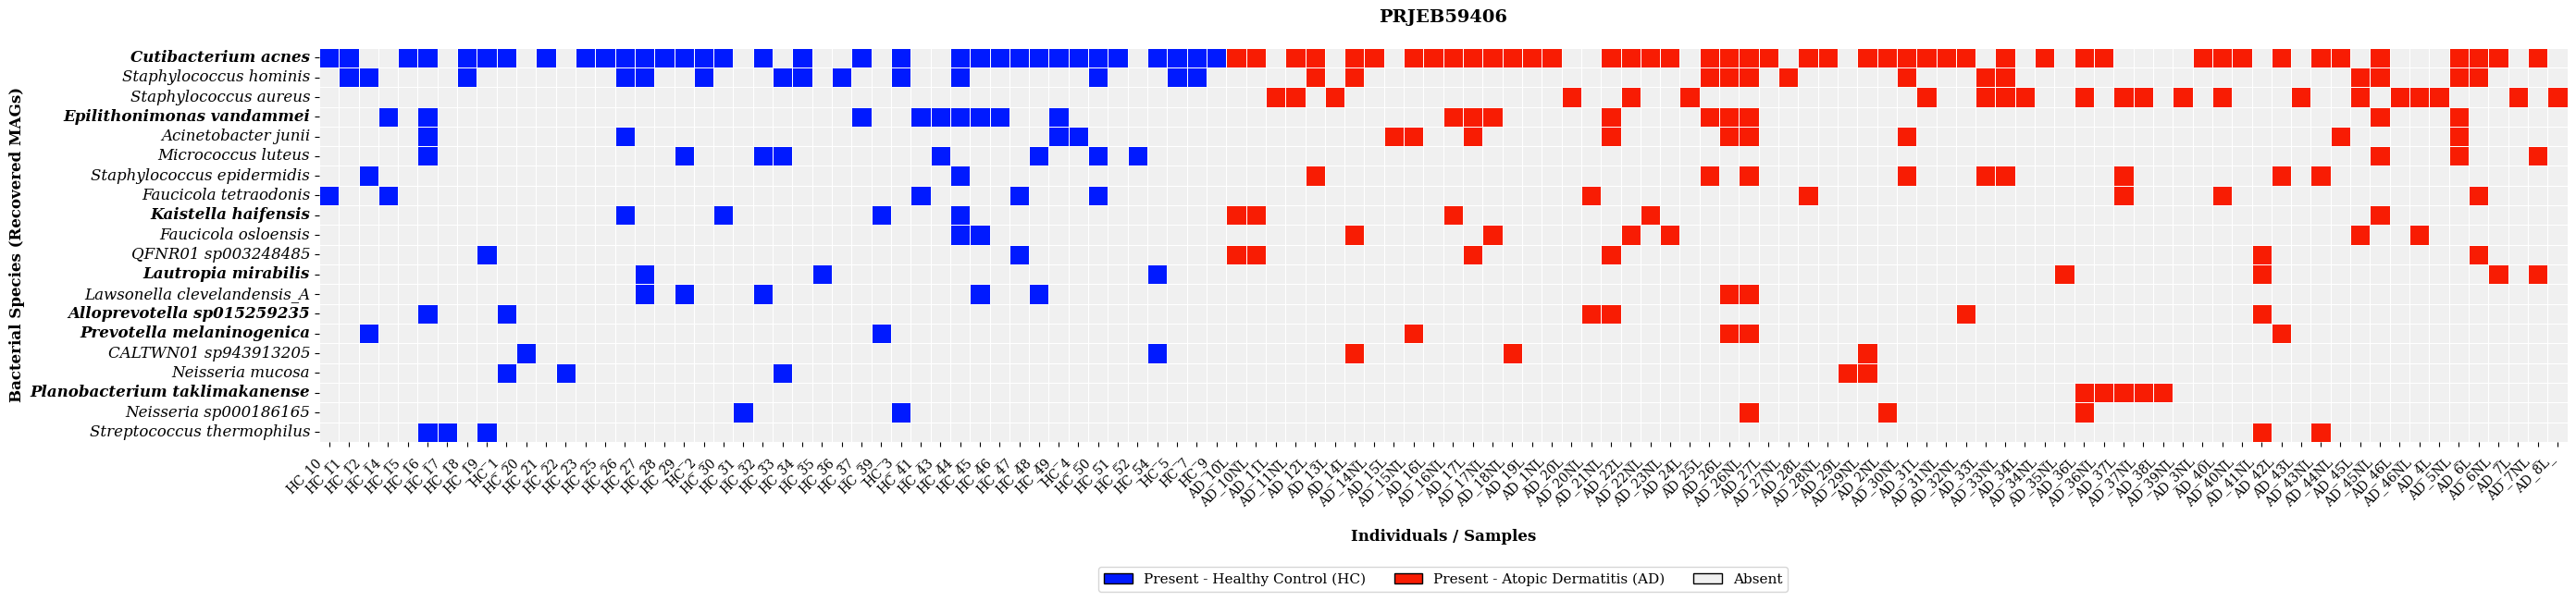

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib import rcParams

# Font and style setup
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']
rcParams['font.size'] = 12

# File paths
DATA_PATH = "/home/marcos/PRJEB59406/table/master_table_mag_sialidase_gtdb_deseq2.tsv"
OUTPUT_PATH = "/home/marcos/Imagens/Resultados in silico/Individuais/Binary_Heatmap_PRJEB59406.png"

GENE_LIST = ['has_nanH', 'has_nanE', 'has_nanK', 'has_nanA', 'has_nanT']

# 1. Load data
df = pd.read_csv(DATA_PATH, sep='\t')

for gene in GENE_LIST:
    if gene in df.columns:
        df[gene] = df[gene].astype(str).str.upper().isin(['YES', 'TRUE', '1'])

perfil_counts = df.groupby(['Species'] + GENE_LIST).size().reset_index(name='count')
perfil_majoritario = perfil_counts.sort_values('count', ascending=False).drop_duplicates('Species')

df = pd.merge(df, perfil_majoritario[['Species'] + GENE_LIST], on=['Species'] + GENE_LIST)

# 2. Filter top 20 species 
top_20_species = df['Species'].value_counts().nlargest(20).index
df = df[df['Species'].isin(top_20_species)].copy()

# 3. Identify nanH positive species
if 'has_nanH' in df.columns:
    nanH_positive_species = set(
        df[df['has_nanH'] == True]['Species'].unique()
    )
else:
    nanH_positive_species = set()

# Sample ID extraction
def extract_sample_id(mag_id):
    mag_id_str = str(mag_id)
    if '_MAG_' in mag_id_str:
        return mag_id_str.split('_MAG_')[0]
    return 'Co-assembly' if 'MAGScoT' in mag_id_str else mag_id_str

df['Sample'] = df['mag_id'].apply(extract_sample_id)

# 4. Create and sort matrix
binary_matrix = pd.crosstab(df['Species'], df['Sample']).clip(upper=1)
sorted_cols = sorted(binary_matrix.columns, key=lambda x: ('HC' not in x.upper(), x))
binary_matrix = binary_matrix[sorted_cols]
binary_matrix = binary_matrix.loc[binary_matrix.sum(axis=1).sort_values(ascending=False).index]

# 5. Differentiate HC (1) and AD (2) states
for col in binary_matrix.columns:
    if 'HC' not in col.upper():
        binary_matrix[col] = binary_matrix[col].replace(1, 2)

# 6. Plotting setup
plt.figure(figsize=(max(12, len(binary_matrix.columns) * 0.9), max(7, len(binary_matrix.index) * 0.35)))
binary_cmap = mcolors.ListedColormap(['#f0f0f0', '#001aff', '#f81c03'])

ax = sns.heatmap(binary_matrix, cmap=binary_cmap, linewidths=0.5, linecolor='white', 
                 cbar=False, square=True, vmin=0, vmax=2)

# Labels and titles
plt.title("PRJEB59406", fontweight='bold', fontsize=14, pad=20)
plt.ylabel("Bacterial Species (Recovered MAGs)", fontweight='bold', fontsize=12)
plt.xlabel("Individuals / Samples", fontweight='bold', fontsize=12, labelpad=15)

# Format Y-axis labels (dynamic bold)
for label in ax.get_yticklabels():
    species_name = label.get_text()
    if species_name in nanH_positive_species:
        label.set_fontweight('bold')
    else:
        label.set_fontweight('normal')
    label.set_fontstyle('italic')

plt.setp(ax.get_xticklabels(), rotation=45, horizontalalignment='right', fontsize=10)

# Legend setup
legend_elements = [
    Patch(facecolor="#001aff", edgecolor='black', label='Present - Healthy Control (HC)'),
    Patch(facecolor="#f81c03", edgecolor='black', label='Present - Atopic Dermatitis (AD)'),
    Patch(facecolor='#f0f0f0', edgecolor='black', label='Absent')
]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=3, frameon=True, fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib import rcParams

# Font and style setup
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']
rcParams['font.size'] = 12

# File paths
DATA_PATH = "/home/marcos/PRJNA489681/table/master_table_mag_sialidase_gtdb_deseq2.tsv"
OUTPUT_PATH = "/home/marcos/Imagens/Resultados in silico/Individuais/Binary_Heatmap_PRJNA489681.png"

# List of genes to define the metabolic profile
GENE_LIST = ['has_nanH', 'has_nanE', 'has_nanK', 'has_nanA', 'has_nanT']

# 1. Load data
df = pd.read_csv(DATA_PATH, sep='\t')

# ── FILTER ──────────────────────────────────────
for gene in GENE_LIST:
    if gene in df.columns:
        df[gene] = df[gene].astype(str).str.upper().isin(['YES', 'TRUE', '1'])

perfil_counts = df.groupby(['Species'] + GENE_LIST).size().reset_index(name='count')
perfil_majoritario = perfil_counts.sort_values('count', ascending=False).drop_duplicates('Species')

df = pd.merge(df, perfil_majoritario[['Species'] + GENE_LIST], on=['Species'] + GENE_LIST)

# 2. Filter top 20 species 
top_20_species = df['Species'].value_counts().nlargest(20).index
df = df[df['Species'].isin(top_20_species)].copy()

# 3. Identify nanH positive species
if 'has_nanH' in df.columns:
    nanH_positive_species = set(
        df[df['has_nanH'] == True]['Species'].unique()
    )
else:
    nanH_positive_species = set()

# Sample ID extraction
def extract_sample_id(mag_id):
    mag_id_str = str(mag_id)
    if '_MAG_' in mag_id_str:
        return mag_id_str.split('_MAG_')[0]
    return 'Co-assembly' if 'MAGScoT' in mag_id_str else mag_id_str

df['Sample'] = df['mag_id'].apply(extract_sample_id)

# 4. Create and sort matrix
binary_matrix = pd.crosstab(df['Species'], df['Sample']).clip(upper=1)
sorted_cols = sorted(binary_matrix.columns, key=lambda x: ('HC' not in x.upper(), x))
binary_matrix = binary_matrix[sorted_cols]
binary_matrix = binary_matrix.loc[binary_matrix.sum(axis=1).sort_values(ascending=False).index]

# 5. Differentiate HC (1) and AD (2) states
for col in binary_matrix.columns:
    if 'HC' not in col.upper():
        binary_matrix[col] = binary_matrix[col].replace(1, 2)

# 6. Plotting setup
plt.figure(figsize=(max(12, len(binary_matrix.columns) * 0.9), max(7, len(binary_matrix.index) * 0.35)))
binary_cmap = mcolors.ListedColormap(['#f0f0f0', '#001aff', '#f81c03'])

ax = sns.heatmap(binary_matrix, cmap=binary_cmap, linewidths=0.5, linecolor='white', 
                 cbar=False, square=True, vmin=0, vmax=2)

# Labels and titles
plt.title("PRJNA489681", fontweight='bold', fontsize=14, pad=20)
plt.ylabel("Bacterial Species (Recovered MAGs)", fontweight='bold', fontsize=12)
plt.xlabel("Individuals / Samples", fontweight='bold', fontsize=12, labelpad=15)

# Format Y-axis labels (dynamic bold)
for label in ax.get_yticklabels():
    species_name = label.get_text()
    if species_name in nanH_positive_species:
        label.set_fontweight('bold')
    else:
        label.set_fontweight('normal')
    label.set_fontstyle('italic')

plt.setp(ax.get_xticklabels(), rotation=45, horizontalalignment='right', fontsize=10)

# Legend setup
legend_elements = [
    Patch(facecolor="#001aff", edgecolor='black', label='Present - Healthy Control (HC)'),
    Patch(facecolor="#f81c03", edgecolor='black', label='Present - Atopic Dermatitis (AD)'),
    Patch(facecolor='#f0f0f0', edgecolor='black', label='Absent')
]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=3, frameon=True, fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib import rcParams

# Font and style setup
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']
rcParams['font.size'] = 12

# File paths
DATA_PATH = "/home/marcos/PRJNA46333/PRJNA46333_2/table/master_table_mag_sialidase_gtdb_deseq2.tsv"
OUTPUT_PATH = "/home/marcos/Imagens/Resultados in silico/Individuais/Binary_Heatmap_PRJNA46333.png"

GENE_LIST = ['has_nanH', 'has_nanE', 'has_nanK', 'has_nanA', 'has_nanT']

# 1. Load data
df = pd.read_csv(DATA_PATH, sep='\t')

for gene in GENE_LIST:
    if gene in df.columns:
        df[gene] = df[gene].astype(str).str.upper().isin(['YES', 'TRUE', '1'])

perfil_counts = df.groupby(['Species'] + GENE_LIST).size().reset_index(name='count')
perfil_majoritario = perfil_counts.sort_values('count', ascending=False).drop_duplicates('Species')

df = pd.merge(df, perfil_majoritario[['Species'] + GENE_LIST], on=['Species'] + GENE_LIST)

# 2. Filter top 20 species 
top_20_species = df['Species'].value_counts().nlargest(20).index
df = df[df['Species'].isin(top_20_species)].copy()

# 3. Identify nanH positive species
if 'has_nanH' in df.columns:
    nanH_positive_species = set(
        df[df['has_nanH'] == True]['Species'].unique()
    )
else:
    nanH_positive_species = set()

# Sample ID extraction
def extract_sample_id(mag_id):
    mag_id_str = str(mag_id)
    if '_MAG_' in mag_id_str:
        return mag_id_str.split('_MAG_')[0]
    return 'Co-assembly' if 'MAGScoT' in mag_id_str else mag_id_str

df['Sample'] = df['mag_id'].apply(extract_sample_id)

# 4. Create and sort matrix
binary_matrix = pd.crosstab(df['Species'], df['Sample']).clip(upper=1)
sorted_cols = sorted(binary_matrix.columns, key=lambda x: ('HC' not in x.upper(), x))
binary_matrix = binary_matrix[sorted_cols]
binary_matrix = binary_matrix.loc[binary_matrix.sum(axis=1).sort_values(ascending=False).index]

# 5. Differentiate HC (1) and AD (2) states
for col in binary_matrix.columns:
    if 'HC' not in col.upper():
        binary_matrix[col] = binary_matrix[col].replace(1, 2)

# 6. Plotting setup
plt.figure(figsize=(max(12, len(binary_matrix.columns) * 0.9), max(7, len(binary_matrix.index) * 0.35)))
binary_cmap = mcolors.ListedColormap(['#f0f0f0', '#001aff', '#f81c03'])

ax = sns.heatmap(binary_matrix, cmap=binary_cmap, linewidths=0.5, linecolor='white', 
                 cbar=False, square=True, vmin=0, vmax=2)

# Labels and titles
plt.title("PRJNA46333", fontweight='bold', fontsize=14, pad=20)
plt.ylabel("Bacterial Species (Recovered MAGs)", fontweight='bold', fontsize=12)
plt.xlabel("Individuals / Samples", fontweight='bold', fontsize=12, labelpad=15)

# Format Y-axis labels (dynamic bold)
for label in ax.get_yticklabels():
    species_name = label.get_text()
    if species_name in nanH_positive_species:
        label.set_fontweight('bold')
    else:
        label.set_fontweight('normal')
    label.set_fontstyle('italic')

plt.setp(ax.get_xticklabels(), rotation=45, horizontalalignment='right', fontsize=10)

# Legend setup
legend_elements = [
    Patch(facecolor="#001aff", edgecolor='black', label='Present - Healthy Control (HC)'),
    Patch(facecolor="#f81c03", edgecolor='black', label='Present - Atopic Dermatitis (AD)'),
    Patch(facecolor='#f0f0f0', edgecolor='black', label='Absent')
]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=3, frameon=True, fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight')
plt.show()

Integration of three studys

Differencial Expression of Individual MAGs and Sialic Acid Metabolism Across Three Studies

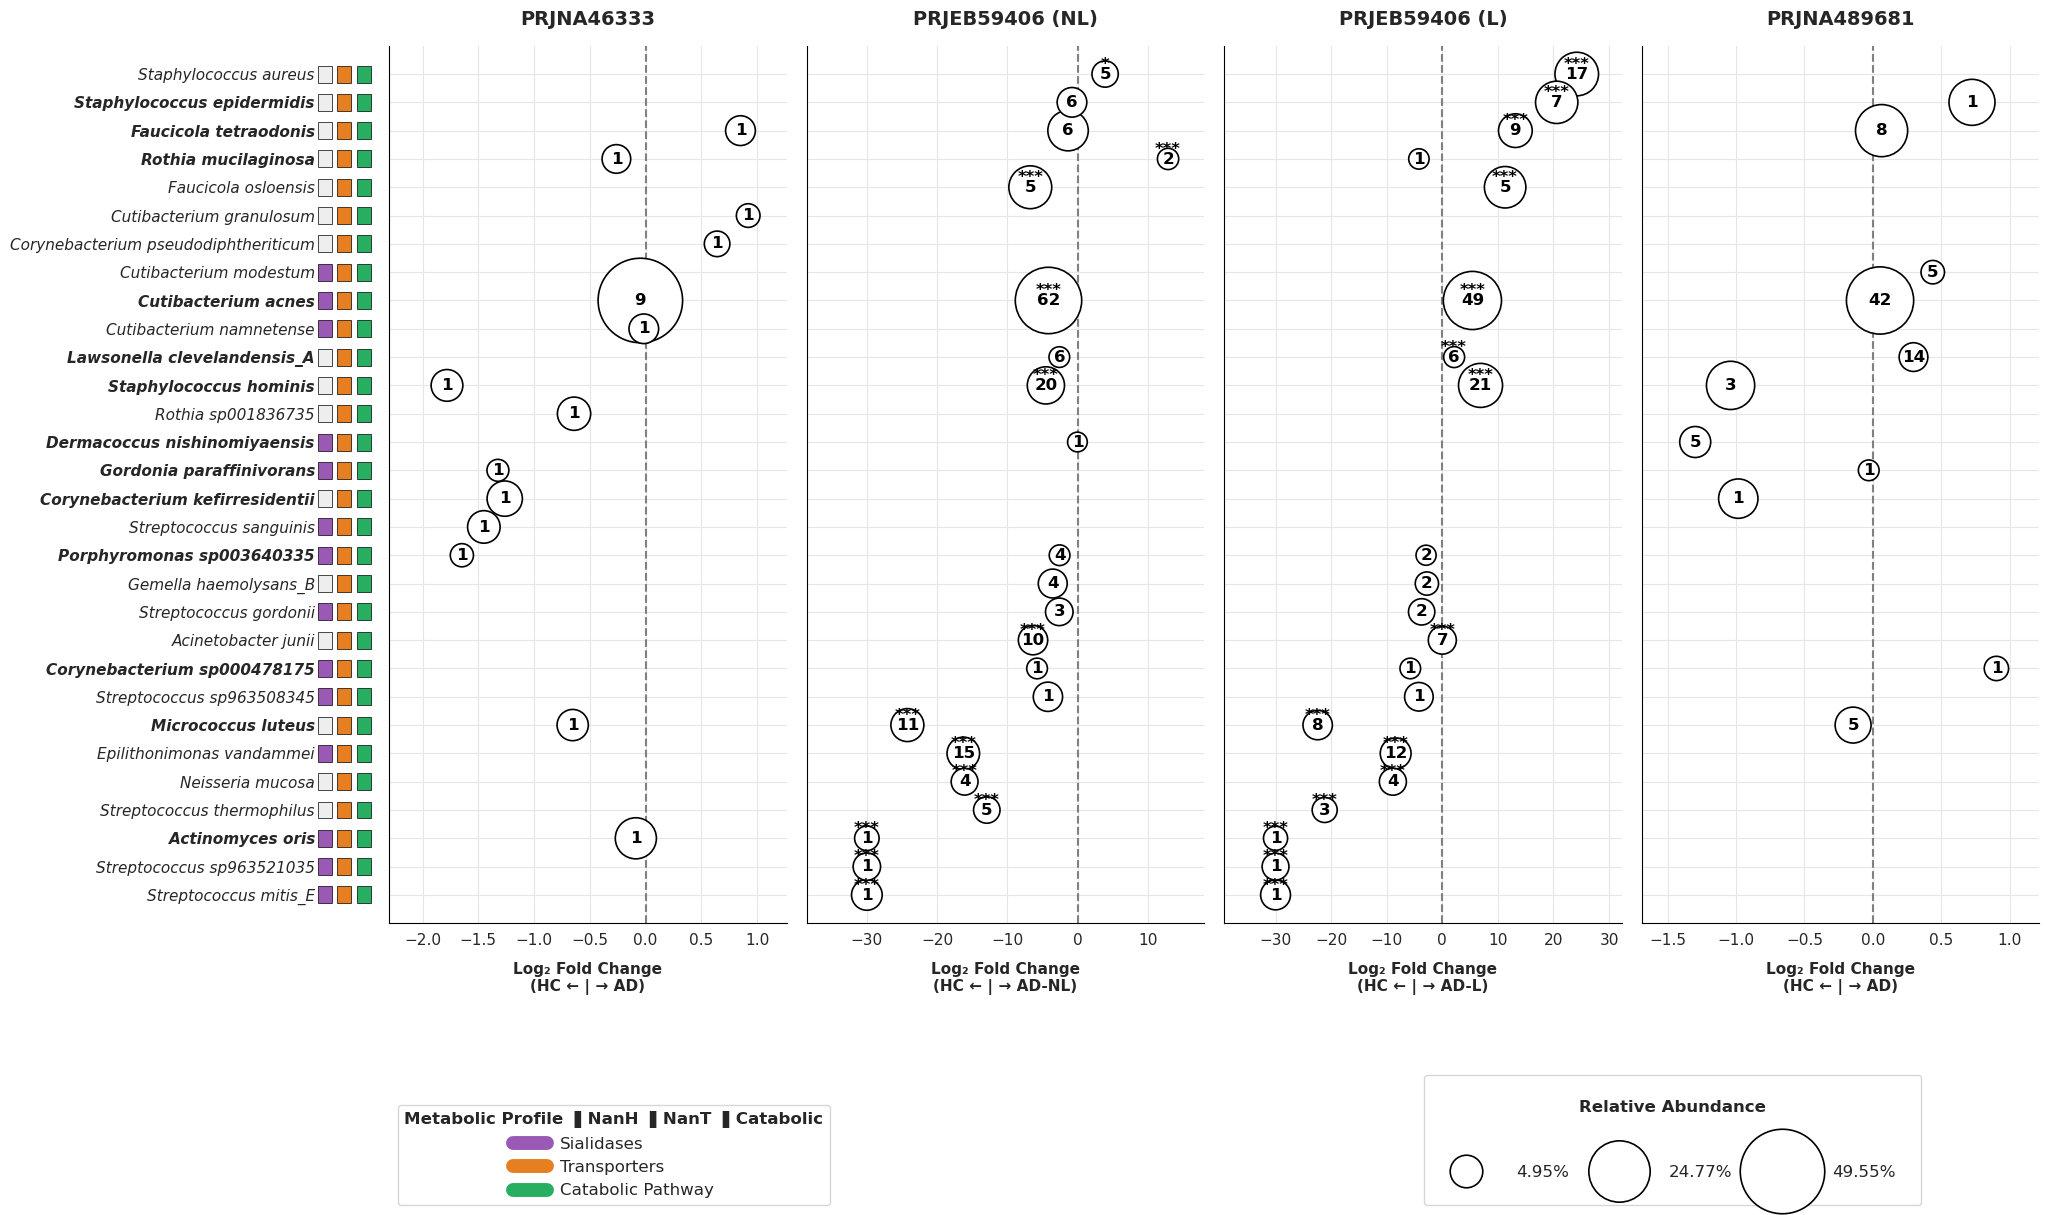

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import os
from matplotlib.lines import Line2D
from matplotlib import rcParams

# ── 1. STYLE CONFIGURATION ──────────────────────────────────────────────────
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']
rcParams['font.size'] = 12

sns.set_style("whitegrid", {'axes.edgecolor': 'black', 'grid.color': '.90', 'grid.linestyle': '-'})

# ── 2. PATHWAYS AND SETTINGS ────────────────────────────────────────────────
STUDIES = {
    'PRJNA46333': "/home/marcos/PRJNA46333/PRJNA46333_2/table/master_table_mag_sialidase_gtdb_deseq2.tsv",
    'PRJEB59406': "/home/marcos/PRJEB59406/table/master_table_mag_sialidase_gtdb_deseq2.tsv", 
    'PRJNA489681': "/home/marcos/PRJNA489681/table/master_table_mag_sialidase_gtdb_deseq2.tsv"
}

OUTPUT_PATH = "/home/marcos/Imagens/Resultados in silico/Geral/Final_DESeq2_Metabolic_Plot_Panels.png"

METABOLIC_PALETTE = {
    'Sialidases': '#9b59b6',
    'Transporters': '#e67e22',
    'Catabolic Pathway': '#27ae60',
    'Inactive': '#eeeeee'
}
GENE_LIST = ['has_nanH', 'has_nanE', 'has_nanK', 'has_nanA', 'has_nanT']

# ── 3. DATA INTEGRATION (Com Separação Dinâmica) ─────────────────────────────
df_list = []
plot_studies = [] 

for study_id, path in STUDIES.items():
    if os.path.exists(path):
        temp_df = pd.read_csv(path, sep='\t')
        
        # Regra de separação exclusiva para o estudo PRJEB59406
        if study_id == 'PRJEB59406':
            # 1. Separar o estudo NL
            mask_nl = temp_df['mag_id'].str.contains('NL__', na=False) | temp_df['mag_id'].str.contains('HC_', na=False)
            df_nl = temp_df[mask_nl].copy()
            study_nl_name = 'PRJEB59406 (NL)'
            df_nl['Study'] = study_nl_name
            df_list.append(df_nl)
            plot_studies.append(study_nl_name)
            
            # 2. Separar o estudo L
            mask_l = (temp_df['mag_id'].str.contains('L__', na=False) & ~temp_df['mag_id'].str.contains('NL__', na=False)) | temp_df['mag_id'].str.contains('HC_', na=False)
            df_l = temp_df[mask_l].copy()
            study_l_name = 'PRJEB59406 (L)'
            df_l['Study'] = study_l_name
            df_list.append(df_l)
            plot_studies.append(study_l_name)
            
        else:
            temp_df['Study'] = study_id
            df_list.append(temp_df)
            plot_studies.append(study_id)
    else:
        print(f"File not found: {path}")

if not df_list:
    raise FileNotFoundError("Nenhum arquivo DESeq2 foi encontrado.")

df = pd.concat(df_list, ignore_index=True)

for col in ['baseMean', 'log2FoldChange', 'padj']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['padj'] = df['padj'].fillna(1.0)
df['log2FoldChange'] = df['log2FoldChange'].fillna(0.0)
df['baseMean'] = df['baseMean'].fillna(0.0)

for gene in GENE_LIST:
    if gene in df.columns:
        df[gene] = df[gene].astype(str).str.upper().isin(['YES', 'TRUE', '1'])

# ── 4. AGGREGATION AND FILTERING ────────────────────────────────────────────
perfil_counts = df.groupby(['Species'] + GENE_LIST).size().reset_index(name='count')
perfil_majoritario = perfil_counts.sort_values('count', ascending=False).drop_duplicates('Species')

df_filtrado = pd.merge(df, perfil_majoritario[['Species'] + GENE_LIST], on=['Species'] + GENE_LIST)

bin_counts = df_filtrado.groupby(['Study', 'Species']).size().reset_index(name='bin_count')

df_agg = df_filtrado.groupby(['Study', 'Species']).agg({
    'baseMean': 'sum',
    'log2FoldChange': 'mean',
    'padj': 'min',
    **{g: 'any' for g in GENE_LIST if g in df_filtrado.columns}
}).reset_index()

df_agg = pd.merge(df_agg, bin_counts, on=['Study', 'Species'])

# Sum baseMean across studies for each species
all_study = df_agg.groupby('Study')['baseMean'].transform('sum')
df_agg['Relative_Abundance'] = (df_agg['baseMean'] / all_study) * 100

# --- NOVA REGRA PARA O NEGRITO ---
# Extrai apenas o nome base do estudo (ex: "PRJEB59406 (NL)" vira "PRJEB59406")
df_agg['Base_Study'] = df_agg['Study'].apply(lambda x: x.split(' ')[0])

# Conta em quantos estudos base a bactéria apareceu
study_counts = df_agg.groupby('Species')['Base_Study'].nunique()
multi_study_species = set(study_counts[study_counts >= 2].index)

top_30_species = df_agg.groupby('Species')['baseMean'].sum().nlargest(30).index.tolist()
df_plot = df_agg[df_agg['Species'].isin(top_30_species)].copy()

species_order = df_plot.groupby('Species')['log2FoldChange'].mean().sort_values().index.tolist()
sp_to_y = {sp: i for i, sp in enumerate(species_order)}
df_plot['Y_idx'] = df_plot['Species'].map(sp_to_y)

# ── 5. RELATIVE ABUNDANCE ───────────────────────────────────────────────────
study_totals = df_plot.groupby('Study')['baseMean'].transform('sum')
df_plot['Relative_Abundance'] = (df_plot['baseMean'] / study_totals) * 100

# ── 6. FIGURE CONFIGURATION ─────────────────────────────────────────────────
num_sp = len(species_order)
num_panels = len(plot_studies) # Continua mantendo as 4 colunas visuais

fig, axes = plt.subplots(1, num_panels, figsize=(5.5 * num_panels, max(10, num_sp * 0.45)), 
                         sharey=True, gridspec_kw={'wspace': 0.05})

if num_panels == 1:
    axes = [axes]

meta_df = df_plot.groupby('Species').agg({g: 'any' for g in GENE_LIST}).reset_index()

# ── 7. PLOTTING LOOP ────────────────────────────────────────────────────────
for ax, study in zip(axes, plot_studies):
    sub_df = df_plot[df_plot['Study'] == study]
    
    sizes = (sub_df['Relative_Abundance'] / df_plot['Relative_Abundance'].max() * 3500) + 200
    
    ax.scatter(x=sub_df['log2FoldChange'], y=sub_df['Y_idx'], s=sizes, color='white', 
               edgecolors='black', linewidths=1.2, alpha=1.0, zorder=3)
    
    for _, row in sub_df.iterrows():
        ax.text(row['log2FoldChange'], row['Y_idx'], str(int(row['bin_count'])), 
                ha='center', va='center', fontsize=12, fontweight='bold', color='black', zorder=4)
        
        sig = "***" if row['padj'] < 0.001 else "**" if row['padj'] < 0.01 else "*" if row['padj'] < 0.05 else ""
        if sig:
            ax.text(row['log2FoldChange'], row['Y_idx'] + 0.35, sig, ha='center', va='center',
                    fontsize=12, fontweight='bold', color='black', zorder=4)
            
    ax.axvline(x=0, color='gray', linestyle='--', lw=1.5, zorder=1)
    ax.set_title(f"{study}", fontweight='bold', fontsize=14, pad=15)
    
    # Textos do Eixo X dinâmicos
    if "(NL)" in study:
        ax.set_xlabel("Log₂ Fold Change\n(HC ← | → AD-NL)", fontsize=11, fontweight='bold', labelpad=10)
    elif "(L)" in study:
        ax.set_xlabel("Log₂ Fold Change\n(HC ← | → AD-L)", fontsize=11, fontweight='bold', labelpad=10)
    else:
        ax.set_xlabel("Log₂ Fold Change\n(HC ← | → AD)", fontsize=11, fontweight='bold', labelpad=10)
    
    ax.tick_params(axis='x', labelsize=11)
    
    xmin, xmax = ax.get_xlim()
    ax.set_xlim(xmin * 1.20, xmax * 1.20)
    ax.set_ylim(-1, num_sp)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── 8. Y-AXIS LABELS AND METABOLIC BARS ─────────────────────────────────────
axes[0].set_yticks(range(num_sp))
axes[0].set_yticklabels(species_order, fontstyle='italic', fontsize=11)
axes[0].tick_params(axis='y', pad=50) 

# Aplica o negrito considerando a nova regra baseada no Base_Study
for label in axes[0].get_yticklabels():
    if label.get_text() in multi_study_species:
        label.set_fontweight('bold')

for i, sp in enumerate(species_order):
    if sp in meta_df['Species'].values:
        row = meta_df[meta_df['Species'] == sp].iloc[0]
        metabolic_info = [('has_nanH', 'Sialidases'), ('has_nanT', 'Transporters'), ('cat', 'Catabolic Pathway')]

        for j, (g_key, p_key) in enumerate(metabolic_info):
            if g_key == 'cat':
                present = any(row.get(g, False) for g in ['has_nanA', 'has_nanE', 'has_nanK'])
            else:
                present = row.get(g_key, False)

            color = METABOLIC_PALETTE[p_key] if present else METABOLIC_PALETTE['Inactive']
            axes[0].add_patch(plt.Rectangle((-0.18 + (j * 0.05), i - 0.30), 0.035, 0.60, clip_on=False,
                                            transform=axes[0].get_yaxis_transform(), facecolor=color, edgecolor='black', lw=0.5))

# ── 9. GLOBAL LEGEND ────────────────────────────────────────────────────────
size_samples = [df_plot['Relative_Abundance'].max() * 0.1, df_plot['Relative_Abundance'].max() * 0.5, df_plot['Relative_Abundance'].max()]
size_legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=f'{val:.2f}%',
           markerfacecolor='white', markeredgecolor='black', markeredgewidth=1.2, alpha=1.0,
           markersize=np.sqrt(((val / df_plot['Relative_Abundance'].max()) * 3500) + 200))
    for val in size_samples if val > 0
]
if size_legend_elements:
    fig.legend(handles=size_legend_elements, title="Relative Abundance",
               loc='lower right', bbox_to_anchor=(0.90, 0.0351), ncol=3, frameon=True,
               title_fontproperties={'weight': 'bold'},
               labelspacing=3.0, borderpad=1.5, handletextpad=2.0)    
    
legend_els = [Line2D([0], [0], color=c, lw=10, label=l) for l, c in METABOLIC_PALETTE.items() if l != 'Inactive']
fig.legend(handles=legend_els, title="Metabolic Profile  ▌NanH  ▌NanT  ▌Catabolic",
           loc='lower left', bbox_to_anchor=(0.2, 0.0351), ncol=1, frameon=True,
           title_fontproperties={'weight': 'bold'})

# ── 10. LAYOUT & SAVE ───────────────────────────────────────────────────────
plt.subplots_adjust(left=0.20, right=0.95, top=0.90, bottom=0.25)
plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight')
plt.show()

Beta and alpha diversity analysis

Samples found:
Condition
HC       54
AD-NL    45
AD-L     44
Name: count, dtype: int64

Calculating Alpha Diversity...
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

HC vs. AD-NL: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:7.037e-02 U_stat=1.473e+03
AD-NL vs. AD-L: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:4.949e-04 U_stat=1.415e+03
HC vs. AD-L: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:4.029e-07 U_stat=1.898e+03


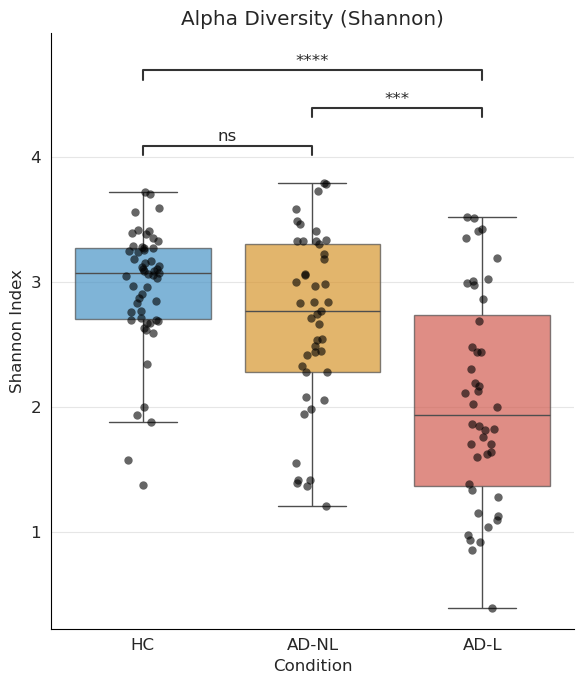


Calculating Beta Diversity and PCoA...


/home/marcos/miniconda3/lib/python3.13/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:164: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(


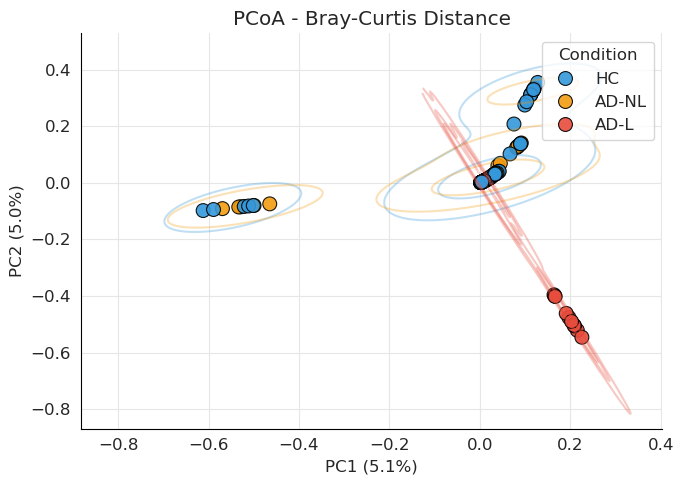


Running PERMANOVA Global (999 permutations)...

=== Resultado da PERMANOVA Global ===
method name               PERMANOVA
test statistic name        pseudo-F
sample size                     143
number of groups                  3
test statistic              3.45504
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object

=== Beta Diversity: Comparações Par a Par (PERMANOVA) ===
HC vs AD-NL: p-value = 0.2950 | q-value (FDR) = 0.2950
HC vs AD-L: p-value = 0.0010 | q-value (FDR) = 0.0015
AD-NL vs AD-L: p-value = 0.0010 | q-value (FDR) = 0.0015


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from scipy.stats import kruskal, mannwhitneyu
from skbio.diversity import alpha_diversity, beta_diversity
from skbio.stats.ordination import pcoa
from skbio.stats.distance import permanova
from statsmodels.stats.multitest import multipletests
from statannotations.Annotator import Annotator

# ==============================================================================
# 1. LOAD AND PREPARE DATA
# ==============================================================================

# Caminho original restaurado
path = "/home/marcos/PRJEB59406/table/mag_abundance/mag_abundance_all.tsv"

# Load data, clean column names, and transpose (samples as rows, MAGs as columns)
df = pd.read_csv(path, sep='\t', index_col=0)
df.columns = df.columns.str.replace('.sorted Read Count', '', regex=False)
df = df.T

# Filter out samples with 0 total reads
df = df[df.sum(axis=1) > 0]

# Infer conditions: Separar HC, AD-NL e AD-L dinamicamente
def get_condition(sample_name):
    if sample_name.startswith('HC'):
        return 'HC'
    elif sample_name.startswith('AD'):
        if 'NL' in sample_name:
            return 'AD-NL'
        else:
            return 'AD-L'
    return 'Other'

conditions = [get_condition(name) for name in df.index]
meta = pd.DataFrame({'Condition': conditions}, index=df.index)

print(f"Samples found:\n{meta['Condition'].value_counts()}\n")

# Paleta de cores atualizada para 3 grupos
colors = {"HC": "#3498db", "AD-NL": "#f39c12", "AD-L": "#e74c3c"}
ordem_grupos = ['HC', 'AD-NL', 'AD-L']

# ==============================================================================
# 2. ALPHA DIVERSITY (Shannon)
# ==============================================================================
print("Calculating Alpha Diversity...")

meta['Shannon'] = alpha_diversity('shannon', df.values, ids=df.index)

# Plot (Ajustado tamanho para acomodar as chaves)
fig, ax = plt.subplots(figsize=(6, 7))

sns.boxplot(data=meta, x='Condition', y='Shannon', hue='Condition', palette=colors, 
            order=ordem_grupos, hue_order=ordem_grupos,
            legend=False, showfliers=False, boxprops={'alpha': 0.7}, ax=ax)
sns.stripplot(data=meta, x='Condition', y='Shannon', color='black', 
              order=ordem_grupos, alpha=0.6, jitter=True, size=6, ax=ax)

# Adicionar as chaves de significância estatística
pares = [("HC", "AD-NL"), ("HC", "AD-L"), ("AD-NL", "AD-L")]
annotator = Annotator(ax, pares, data=meta, x='Condition', y='Shannon', order=ordem_grupos)
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside', comparisons_correction='fdr_bh')
annotator.apply_and_annotate()

ax.set(title="Alpha Diversity (Shannon)", xlabel="Condition", ylabel="Shannon Index")
sns.despine()
plt.tight_layout()

# Caminho de saída original restaurado
plt.savefig("/home/marcos/Imagens/Resultados in silico/Individuais/Diversidade_Alfa_CoverM_PRJEB59406.png", dpi=300)
plt.show()

# ==============================================================================
# 3. BETA DIVERSITY & PCoA (Bray-Curtis)
# ==============================================================================
print("\nCalculating Beta Diversity and PCoA...")

rel_abund = df.div(df.sum(axis=1), axis=0)
bc_dm = beta_diversity("braycurtis", rel_abund.values, ids=rel_abund.index)
pcoa_res = pcoa(bc_dm)

pcoa_df = pcoa_res.samples[['PC1', 'PC2']].assign(Condition=meta['Condition'])
pc1_var, pc2_var = pcoa_res.proportion_explained[['PC1', 'PC2']] * 100

# Plot do PCoA com Elipses de Densidade
fig, ax = plt.subplots(figsize=(7, 5))

# 1. Adiciona as linhas de contorno (elipses) no fundo para agrupar visualmente
sns.kdeplot(data=pcoa_df, x='PC1', y='PC2', hue='Condition', palette=colors,
            hue_order=ordem_grupos, alpha=0.3, levels=4, warn_singular=False, ax=ax)

# 2. Desenha os pontos por cima
sns.scatterplot(data=pcoa_df, x='PC1', y='PC2', hue='Condition', palette=colors, 
                hue_order=ordem_grupos, s=100, alpha=0.9, edgecolor='black', ax=ax)

ax.set(title="PCoA - Bray-Curtis Distance", xlabel=f"PC1 ({pc1_var:.1f}%)", ylabel=f"PC2 ({pc2_var:.1f}%)")

# Limpar legenda duplicada gerada pelo kdeplot
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles[:len(ordem_grupos)], labels=labels[:len(ordem_grupos)], title="Condition", frameon=True)

sns.despine()
plt.tight_layout()

# Caminho de saída original restaurado
plt.savefig("/home/marcos/Imagens/Resultados in silico/Individuais/Diversidade_Beta_PCoA_CoverM_PRJEB59406.png", dpi=300)
plt.show()

# ==============================================================================
# 4. PERMANOVA STATISTICS
# ==============================================================================
print("\nRunning PERMANOVA Global (999 permutations)...")
permanova_res = permanova(bc_dm, meta, column='Condition', permutations=999)
print("\n=== Resultado da PERMANOVA Global ===")
print(permanova_res)

print("\n=== Beta Diversity: Comparações Par a Par (PERMANOVA) ===")
p_valores_beta = []

for g1, g2 in pares:
    mask = meta['Condition'].isin([g1, g2])
    meta_par = meta[mask]
    dm_par = bc_dm.filter(meta_par.index)
    
    res_par = permanova(dm_par, meta_par, column='Condition', permutations=999)
    p_valores_beta.append(res_par['p-value'])

_, p_adj_beta, _, _ = multipletests(p_valores_beta, method='fdr_bh')

for (g1, g2), p, padj in zip(pares, p_valores_beta, p_adj_beta):
    print(f"{g1} vs {g2}: p-value = {p:.4f} | q-value (FDR) = {padj:.4f}")

Samples found:
Condition
AD    60
HC    25
Name: count, dtype: int64

Calculating Alpha Diversity...
Mann-Whitney (Shannon): p-value = 0.8207

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

HC vs. AD: Mann-Whitney-Wilcoxon test two-sided, P_val:8.207e-01 U_stat=7.740e+02


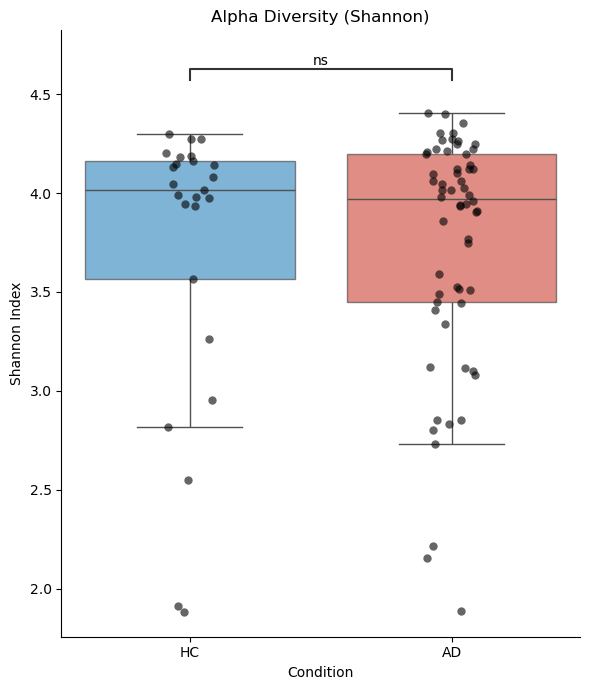


Calculating Beta Diversity and PCoA...


/home/marcos/miniconda3/lib/python3.13/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:164: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(
/home/marcos/miniconda3/lib/python3.13/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:282: RuntimeWarning: The result contains negative eigenvalues that are large in magnitude, which may suggest result inaccuracy. See Notes for details. The negative-most eigenvalue is -0.17513105859657577 whereas the largest positive one is 5.18410222536433.
  warn(


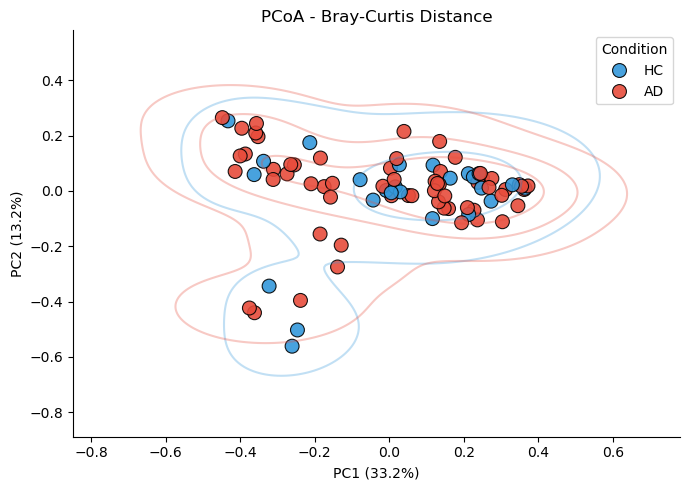


Running PERMANOVA (999 permutations)...

=== PERMANOVA Results ===
method name               PERMANOVA
test statistic name        pseudo-F
sample size                      85
number of groups                  2
test statistic             0.676689
p-value                       0.672
number of permutations          999
Name: PERMANOVA results, dtype: object


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from skbio.diversity import alpha_diversity, beta_diversity
from skbio.stats.ordination import pcoa
from skbio.stats.distance import permanova
from statannotations.Annotator import Annotator

# ==============================================================================
# 1. LOAD AND PREPARE DATA
# ==============================================================================

path = "/home/marcos/PRJNA489681/table/mag_abundance/coverm/mag_abundance_renamed.tsv"

# Load data, clean column names, and transpose (samples as rows, MAGs as columns)
df = pd.read_csv(path, sep='\t', index_col=0)
df.columns = df.columns.str.replace('.sorted Read Count', '', regex=False)
df = df.T

# Filter out samples with 0 total reads
df = df[df.sum(axis=1) > 0]

# Infer conditions (AD or HC) from sample names dynamically
conditions = ['AD' if '_AD_' in name else 'HC' for name in df.index]
meta = pd.DataFrame({'Condition': conditions}, index=df.index)

print(f"Samples found:\n{meta['Condition'].value_counts()}\n")

# Padronização de cores e ordem para 2 grupos
colors = {"HC": "#3498db", "AD": "#e74c3c"}
ordem_grupos = ['HC', 'AD']

# ==============================================================================
# 2. ALPHA DIVERSITY (Shannon) COM CHAVES ESTATÍSTICAS
# ==============================================================================
print("Calculating Alpha Diversity...")

# Calculate Shannon index and add it to the metadata dataframe
meta['Shannon'] = alpha_diversity('shannon', df.values, ids=df.index)

# Statistics: Mann-Whitney U test (apenas para imprimir no terminal)
hc = meta[meta['Condition'] == 'HC']['Shannon']
ad = meta[meta['Condition'] == 'AD']['Shannon']
_, p_val = mannwhitneyu(hc, ad, alternative='two-sided')
print(f"Mann-Whitney (Shannon): p-value = {p_val:.4f}\n")

# Plot (Altura ajustada para 7 para acomodar as chaves)
fig, ax = plt.subplots(figsize=(6, 7))

sns.boxplot(data=meta, x='Condition', y='Shannon', hue='Condition', palette=colors, 
            order=ordem_grupos, hue_order=ordem_grupos,
            legend=False, showfliers=False, boxprops={'alpha': 0.7}, ax=ax)
sns.stripplot(data=meta, x='Condition', y='Shannon', color='black', 
              order=ordem_grupos, alpha=0.6, jitter=True, size=6, ax=ax)

# Configurar e desenhar as anotações (chaves de significância)
pares = [("HC", "AD")]
annotator = Annotator(ax, pares, data=meta, x='Condition', y='Shannon', order=ordem_grupos)
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()

ax.set(title="Alpha Diversity (Shannon)", xlabel="Condition", ylabel="Shannon Index")
sns.despine()
plt.tight_layout()

# Caminho mantido conforme solicitado
plt.savefig("/home/marcos/Imagens/Resultados in silico/Individuais/Alpha_Diversity_PRJNA489681.png", dpi=300)
plt.show()

# ==============================================================================
# 3. BETA DIVERSITY & PCoA (Bray-Curtis)
# ==============================================================================
print("\nCalculating Beta Diversity and PCoA...")

# Convert to relative abundance
rel_abund = df.div(df.sum(axis=1), axis=0)

# Calculate Bray-Curtis distance matrix and run PCoA
bc_dm = beta_diversity("braycurtis", rel_abund.values, ids=rel_abund.index)
pcoa_res = pcoa(bc_dm)

# Extract coordinates and explained variance
pcoa_df = pcoa_res.samples[['PC1', 'PC2']].assign(Condition=meta['Condition'])
pc1_var, pc2_var = pcoa_res.proportion_explained[['PC1', 'PC2']] * 100

# Plot do PCoA com Elipses de Densidade
fig, ax = plt.subplots(figsize=(7, 5))

# 1. Adiciona as linhas de contorno (elipses) no fundo para agrupar visualmente
sns.kdeplot(data=pcoa_df, x='PC1', y='PC2', hue='Condition', palette=colors,
            hue_order=ordem_grupos, alpha=0.3, levels=4, warn_singular=False, ax=ax)

# 2. Desenha os pontos por cima
sns.scatterplot(data=pcoa_df, x='PC1', y='PC2', hue='Condition', palette=colors, 
                hue_order=ordem_grupos, s=100, alpha=0.9, edgecolor='black', ax=ax)

ax.set(title="PCoA - Bray-Curtis Distance", xlabel=f"PC1 ({pc1_var:.1f}%)", ylabel=f"PC2 ({pc2_var:.1f}%)")

# Limpar legenda duplicada gerada pelo kdeplot
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles[:len(ordem_grupos)], labels=labels[:len(ordem_grupos)], title="Condition", frameon=True)

sns.despine()
plt.tight_layout()

# Caminho mantido conforme solicitado
plt.savefig("/home/marcos/Imagens/Resultados in silico/Individuais/Beta_Diversity_PCoA_PRJNA489681.png", dpi=300)
plt.show()

# ==============================================================================
# 4. PERMANOVA STATISTICS
# ==============================================================================
print("\nRunning PERMANOVA (999 permutations)...")

permanova_res = permanova(bc_dm, meta, column='Condition', permutations=999)
print("\n=== PERMANOVA Results ===")
print(permanova_res)

Samples found:
Condition
AD    26
HC     7
Name: count, dtype: int64

Calculating Alpha Diversity...
Mann-Whitney (Shannon): p-value = 1.0000

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

HC vs. AD: Mann-Whitney-Wilcoxon test two-sided, P_val:1.000e+00 U_stat=9.100e+01


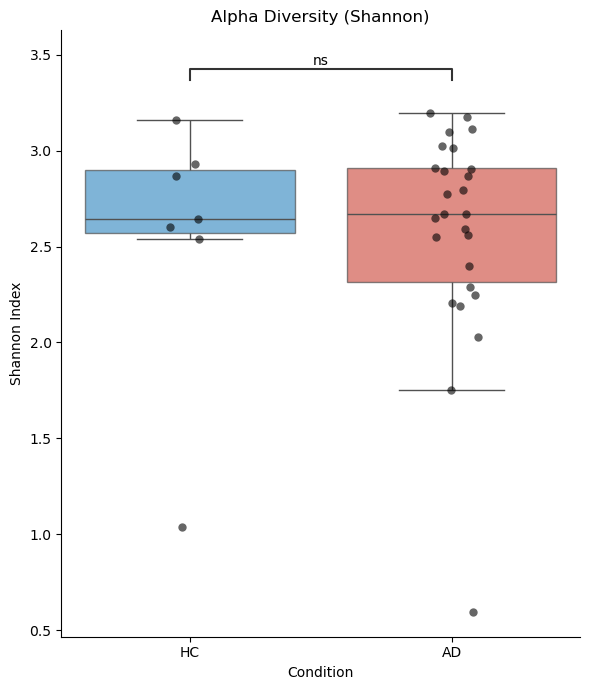


Calculating Beta Diversity and PCoA...


/home/marcos/miniconda3/lib/python3.13/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:164: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(
/home/marcos/miniconda3/lib/python3.13/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:282: RuntimeWarning: The result contains negative eigenvalues that are large in magnitude, which may suggest result inaccuracy. See Notes for details. The negative-most eigenvalue is -0.08740866184402209 whereas the largest positive one is 2.0620670085569737.
  warn(


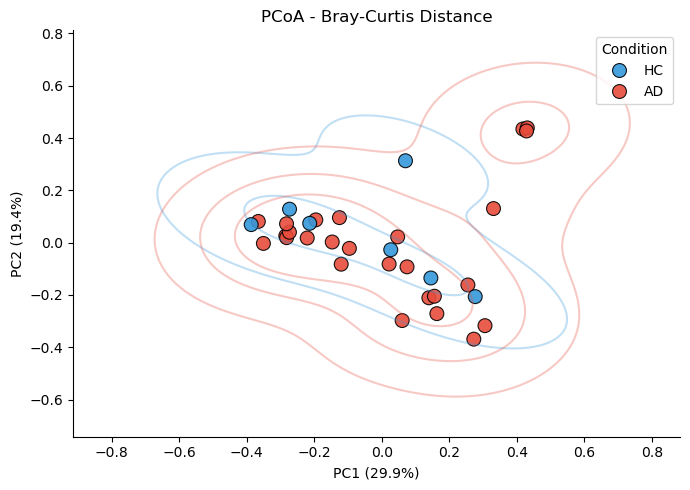


Running PERMANOVA (999 permutations)...

=== PERMANOVA Results ===
method name               PERMANOVA
test statistic name        pseudo-F
sample size                      33
number of groups                  2
test statistic             0.561669
p-value                       0.805
number of permutations          999
Name: PERMANOVA results, dtype: object


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from skbio.diversity import alpha_diversity, beta_diversity
from skbio.stats.ordination import pcoa
from skbio.stats.distance import permanova
from statannotations.Annotator import Annotator

# ==============================================================================
# 1. LOAD AND PREPARE DATA
# ==============================================================================

# Arquivo atualizado
path = "/home/marcos/PRJNA46333/PRJNA46333_2/table/coverm/mag_abundance.tsv"

# Load data, clean column names, and transpose (samples as rows, MAGs as columns)
df = pd.read_csv(path, sep='\t', index_col=0)
df.columns = df.columns.str.replace('.sorted Read Count', '', regex=False)
df = df.T

# Filter out samples with 0 total reads
df = df[df.sum(axis=1) > 0]

# Infer conditions (AD or HC): verifica se a amostra começa com 'AD'
conditions = ['AD' if name.startswith('AD') else 'HC' for name in df.index]
meta = pd.DataFrame({'Condition': conditions}, index=df.index)

print(f"Samples found:\n{meta['Condition'].value_counts()}\n")

# Padronização de cores e ordem para 2 grupos
colors = {"HC": "#3498db", "AD": "#e74c3c"}
ordem_grupos = ['HC', 'AD']

# ==============================================================================
# 2. ALPHA DIVERSITY (Shannon) COM CHAVES ESTATÍSTICAS
# ==============================================================================
print("Calculating Alpha Diversity...")

# Calculate Shannon index and add it to the metadata dataframe
meta['Shannon'] = alpha_diversity('shannon', df.values, ids=df.index)

# Statistics: Mann-Whitney U test (apenas para imprimir no terminal)
hc = meta[meta['Condition'] == 'HC']['Shannon']
ad = meta[meta['Condition'] == 'AD']['Shannon']
_, p_val = mannwhitneyu(hc, ad, alternative='two-sided')
print(f"Mann-Whitney (Shannon): p-value = {p_val:.4f}\n")

# Plot (Altura ajustada para 7 para acomodar a anotação)
fig, ax = plt.subplots(figsize=(6, 7))

sns.boxplot(data=meta, x='Condition', y='Shannon', hue='Condition', palette=colors, 
            order=ordem_grupos, hue_order=ordem_grupos,
            legend=False, showfliers=False, boxprops={'alpha': 0.7}, ax=ax)
sns.stripplot(data=meta, x='Condition', y='Shannon', color='black', 
              order=ordem_grupos, alpha=0.6, jitter=True, size=6, ax=ax)

# --- NOVA PARTE: ADICIONAR AS CHAVES (BRACKETS) ---
pares = [("HC", "AD")]
annotator = Annotator(ax, pares, data=meta, x='Condition', y='Shannon', order=ordem_grupos)

# Configurar o teste de Mann-Whitney para gerar as estrelinhas de significância
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
annotator.apply_and_annotate()

ax.set(title="Alpha Diversity (Shannon)", xlabel="Condition", ylabel="Shannon Index")
sns.despine()
plt.tight_layout()

plt.savefig("/home/marcos/Imagens/Resultados in silico/Individuais/Alpha_Diversity_PRJNA46333.png", dpi=300)
plt.show()

# ==============================================================================
# 3. BETA DIVERSITY & PCoA (Bray-Curtis)
# ==============================================================================
print("\nCalculating Beta Diversity and PCoA...")

# Convert to relative abundance
rel_abund = df.div(df.sum(axis=1), axis=0)

# Calculate Bray-Curtis distance matrix and run PCoA
bc_dm = beta_diversity("braycurtis", rel_abund.values, ids=rel_abund.index)
pcoa_res = pcoa(bc_dm)

# Extract coordinates and explained variance
pcoa_df = pcoa_res.samples[['PC1', 'PC2']].assign(Condition=meta['Condition'])
pc1_var, pc2_var = pcoa_res.proportion_explained[['PC1', 'PC2']] * 100

# Plot do PCoA com Elipses de Densidade
fig, ax = plt.subplots(figsize=(7, 5))

# 1. Adiciona as linhas de contorno (elipses) no fundo para agrupar visualmente
sns.kdeplot(data=pcoa_df, x='PC1', y='PC2', hue='Condition', palette=colors,
            hue_order=ordem_grupos, alpha=0.3, levels=4, warn_singular=False, ax=ax)

# 2. Desenha os pontos por cima
sns.scatterplot(data=pcoa_df, x='PC1', y='PC2', hue='Condition', palette=colors, 
                hue_order=ordem_grupos, s=100, alpha=0.9, edgecolor='black', ax=ax)

ax.set(title="PCoA - Bray-Curtis Distance", xlabel=f"PC1 ({pc1_var:.1f}%)", ylabel=f"PC2 ({pc2_var:.1f}%)")

# Limpar legenda duplicada gerada pelo kdeplot
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles[:len(ordem_grupos)], labels=labels[:len(ordem_grupos)], title="Condition", frameon=True)

sns.despine()
plt.tight_layout()

plt.savefig("/home/marcos/Imagens/Resultados in silico/Individuais/Beta_Diversity_PRJNA46333.png", dpi=300)
plt.show()

# ==============================================================================
# 4. PERMANOVA STATISTICS
# ==============================================================================
print("\nRunning PERMANOVA (999 permutations)...")

permanova_res = permanova(bc_dm, meta, column='Condition', permutations=999)
print("\n=== PERMANOVA Results ===")
print(permanova_res)